# Lab 04 — Standard Stereo Geometry

In [1]:
%matplotlib widget

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2


from pytransform3d.transform_manager import TransformManager
import pytransform3d.camera as pc
import pytransform3d.transformations as pt
import pytransform3d.rotations as pr
import pytransform3d.plot_utils as ppu

# Configure plotting
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "axes.labelsize": 11,
        "axes.titlesize": 12,
    }
)


In [2]:
# Data directory configuration
ROOT_DIR = (Path.cwd().parent / ".data").resolve()
assert ROOT_DIR.exists(), f"Root directory does not exist: {ROOT_DIR}"
LV4_DIR = ROOT_DIR / ".data/LV_4"

OUTPUT_DIR = ROOT_DIR.parent / "artifacts/lab04"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


### Background: pytransform3d Conventions

**pytransform3d** uses a consistent notation for transformations:
- `T_AB`: transformation matrix from frame B to frame A (active transformation)
- `transform_from(R, t)`: builds a 4×4 homogeneous matrix with rotation R and translation t
- The library defaults to **right-handed coordinate systems**
- For cameras: typically x-right, y-down, z-forward (optical frame convention)

**Key functions we'll use:**
- `transform_from(R, t)`: construct 4×4 transform from 3x3 rotation + 3×1 translation
- `invert_transform(T)`: compute T^(-1) efficiently
- `TransformManager`: manages a graph of frames and computes transformation chains
- `plot_transform(ax, A2B, ...)`: visualize a coordinate frame in 3D

**Important Note on Notation:**
- OpenCV convention: `(R, t)` transforms world → camera, where t is the camera origin in camera coords
- Camera center in world: `C_world = -R^T @ t`
- pytransform3d uses homogeneous 4×4 matrices which encapsulate both R and t


> **Task**: create the transforms $\mathbf{T}_{WK_1}$ and $\mathbf{T}_{WK_2}$, register them inside a transform manager, and prepare camera intrinsics for both cameras.

### About TransformManager

The `TransformManager` class from pytransform3d maintains a **directed graph** of coordinate frames and transformations between them. Key features:

**Adding Transforms:**
```python
tm.add_transform("frame_A", "frame_B", T_AB)  # T_AB transforms from B to A
```

**Retrieving Transforms:**
```python
T_AC = tm.get_transform("frame_A", "frame_C")  # Finds shortest path A←...←C
```

**Why Bidirectional Registration?**
- Adding both `world→camera` and `camera→world` allows the graph to traverse in either direction
- This is crucial for computing indirect paths (e.g., K1 → world → K2)

**Visualization:**
- `tm.plot_frames_in(reference_frame)` renders all frames relative to a chosen reference
- Alternatively, manually extract transforms and use `plot_transform()` for finer control

## Review — Transforming World to Camera Coordinates

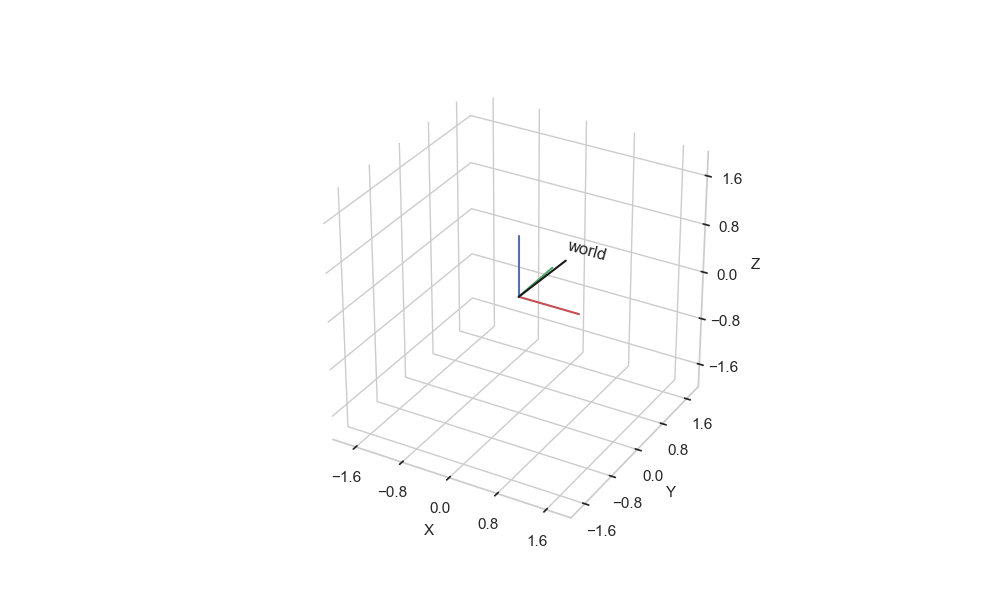

In [3]:
world_frame = pt.transform_from(R=np.eye(3), p=np.array([0.0] * 3))
tm = TransformManager()

plt.figure()
ax = ppu.make_3d_axis(ax_s=2)
pt.plot_transform(ax=ax, A2B=world_frame, s=1, name="world")
plt.show()


In [4]:
f_m = 2e-3  # Focal length in meters
h_px, w_px = 480, 640  # Image height and width in pixels
px_sz_meters = 5e-6
f_px = f_m / px_sz_meters  # Focal length in pixels

# Make x-axis of camera frame to be colinear with [1, 1, 1] in world frame
z_cam_in_world = np.array([1, 1, 1]).T / np.sqrt(3)
world_up = np.array([0, 0, -1]).T
x_cam_in_world = np.cross(world_up, z_cam_in_world)
x_cam_in_world /= np.linalg.norm(x_cam_in_world)
print(f"x_cam_in_world: {x_cam_in_world}")
y_cam_in_world = np.cross(z_cam_in_world, x_cam_in_world)
y_cam_in_world /= np.linalg.norm(y_cam_in_world)
print(f"y_cam_in_world: {y_cam_in_world}")
R_cam_in_world = np.column_stack((x_cam_in_world, y_cam_in_world, z_cam_in_world))

cam2world = pt.transform_from(
    R=R_cam_in_world,
    # R=np.eye(3),
    p=np.array(
        [-0.5, 0.0, 1.0]
    ),  # world coords of camera center (expressed in world (destination) frame)
)
# Note (pt.matrix_from_euler_angles):
# extrinsic=True → angles e[0], e[1], e[2] are rotations about fixed axes i, j, k (in that order).
# extrinsic=False → angles are applied about the moving/body axes (intrinsic).

K = np.array(
    [
        [f_px, 0, w_px / 2],
        [0, f_px, h_px / 2],
        [0, 0, 1],
    ]
)
tm = tm.add_transform(from_frame="cam1", to_frame="world", A2B=cam2world)


x_cam_in_world: [ 0.70710678 -0.70710678  0.        ]
y_cam_in_world: [ 0.40824829  0.40824829 -0.81649658]


In [5]:
ax_angle_cw = pr.axis_angle_from_matrix(tm.get_transform("cam1", "world")[:3, :3])
ax_angle_wc = pr.axis_angle_from_matrix(tm.get_transform("world", "cam1")[:3, :3])

print(f"T:cam1->world:\n{tm.get_transform('cam1', 'world')}")
print(
    f"cam->world axis-angle: {ax_angle_cw[:3]}, angle (deg): {np.rad2deg(ax_angle_cw[3])}"
)
print(
    f"world->cam axis-angle: {ax_angle_wc[:3]}, angle (deg): {np.rad2deg(ax_angle_wc[3])}"
)

print(
    "Euler angles (deg) world->cam:",
    np.rad2deg(
        pr.euler_from_matrix(
            tm.get_transform("cam1", "world")[:3, :3], 0, 1, 2, extrinsic=True
        )
    ),
    "\nEuler angles (deg) cam->world:",
    np.rad2deg(
        pr.euler_from_matrix(
            tm.get_transform("world", "cam1")[:3, :3], 0, 1, 2, extrinsic=True
        )
    ),
)


T:cam1->world:
[[ 0.70710678  0.40824829  0.57735027 -0.5       ]
 [-0.70710678  0.40824829  0.57735027  0.        ]
 [ 0.         -0.81649658  0.57735027  1.        ]
 [ 0.          0.          0.          1.        ]]
cam->world axis-angle: [-0.74290606  0.30772176 -0.5944728 ], angle (deg): 69.73561031724535
world->cam axis-angle: [ 0.74290606 -0.30772176  0.5944728 ], angle (deg): 69.73561031724535
Euler angles (deg) world->cam: [-54.73561032   0.         -45.        ] 
Euler angles (deg) cam->world: [ 45.         -35.26438968  30.        ]


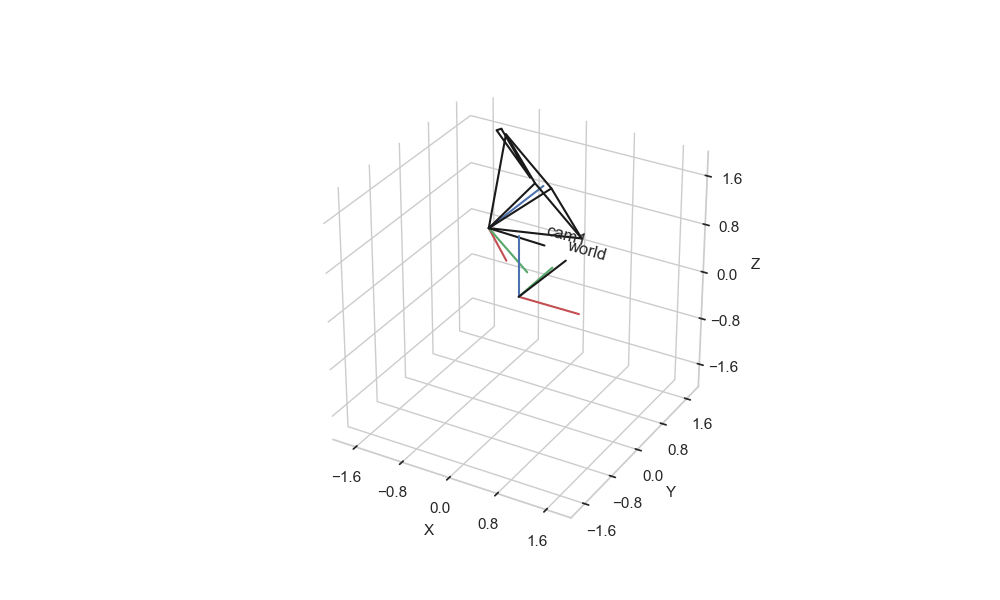

In [6]:
plt.figure()
ax = ppu.make_3d_axis(ax_s=2)
tm.plot_frames_in("world", ax=ax, ax_s=1)
# tm.plot_connections_in("world", ax=ax)
pc.plot_camera(
    ax=ax,
    M=K,
    cam2world=tm.get_transform(from_frame="cam1", to_frame="world"),
    sensor_size=(w_px, h_px),
    ax_s=0.5,
    virtual_image_distance=1,
)
plt.show()


## 7.1.4.2 Define Coordinate Systems and Cameras

We build three coordinate frames: the world frame $W$, and two cameras $K_1$ and $K_2$. To stay close to the MATLAB instructions, we keep identity rotations and translate only along the $x$-axis while keeping both cameras at $z = 1\,\text{m}$. Use `pytransform3d.transform_manager.TransformManager` or explicit homogenous matrices from `pytransform3d.transformations` to manage the frames.

Reference: [pytransform3d documentation on transformations](https://pytransform3d.readthedocs.io/en/latest/transformations.html).

Follow these requirements exactly:
- World frame $W$: origin $\mathbf{t}_W = [0, 0, 0]^\top$ with zero rotation.
- Camera $K_1$: origin $\mathbf{t}_{K_1} = [-0.5, 0, 1]^\top$ meters, identity rotation.
- Camera $K_2$: origin $\mathbf{t}_{K_2} = [0.5, 0, 1]^\top$ meters, identity rotation.
- Both cameras are pinhole models with focal length $f = 0.002\,\text{m}$ and no distortion.
- Visualize each frame with `pytransform3d.visualizer.plot_transform` or `open3d.geometry.TriangleMesh.create_coordinate_frame`, using black for $W$, red for $K_1$, and blue for $K_2$, and label axes.

In [69]:
f_m = 2e-3  # Focal length in meters
h_px, w_px = 480, 640  # Image height and width in pixels
px_sz_meters = 5e-6
f_px = f_m / px_sz_meters  # Focal length in pixels

K = np.array(
    [
        [f_px, 0, w_px / 2],
        [0, f_px, h_px / 2],
        [0, 0, 1],
    ]
)

# Rot 90 about X axis (to look towards xz plane of world frame)
R2 = np.array(
    [
        [1, 0, 0],
        [0, 0, 1],
        [0, -1, 0],
    ]
)
R = pr.matrix_from_axis_angle([1, 0, 0, -np.pi / 2])
assert np.allclose(R2, R)

tm = (
    TransformManager()
    .add_transform(
        from_frame="cam1",
        to_frame="world",
        A2B=pt.transform_from(
            R=R,
            p=np.array([-0.5, 0.0, 1.0]),
        ),
    )
    .add_transform(
        from_frame="cam2",
        to_frame="world",
        A2B=pt.transform_from(
            R=R,
            p=np.array([0.5, 0.0, 1.0]),
        ),
    )
)
print(f"Connected Components: {tm.connected_components()},\n Nodes: {tm.nodes}")


Connected Components: 1,
 Nodes: ['cam1', 'world', 'cam2']


In [70]:
cam1_2_cam2 = pt.invert_transform(tm.get_transform("cam2", "world")) @ tm.get_transform(
    "cam1", "world"
)
assert np.allclose(cam1_2_cam2, tm.get_transform("cam1", "cam2"))


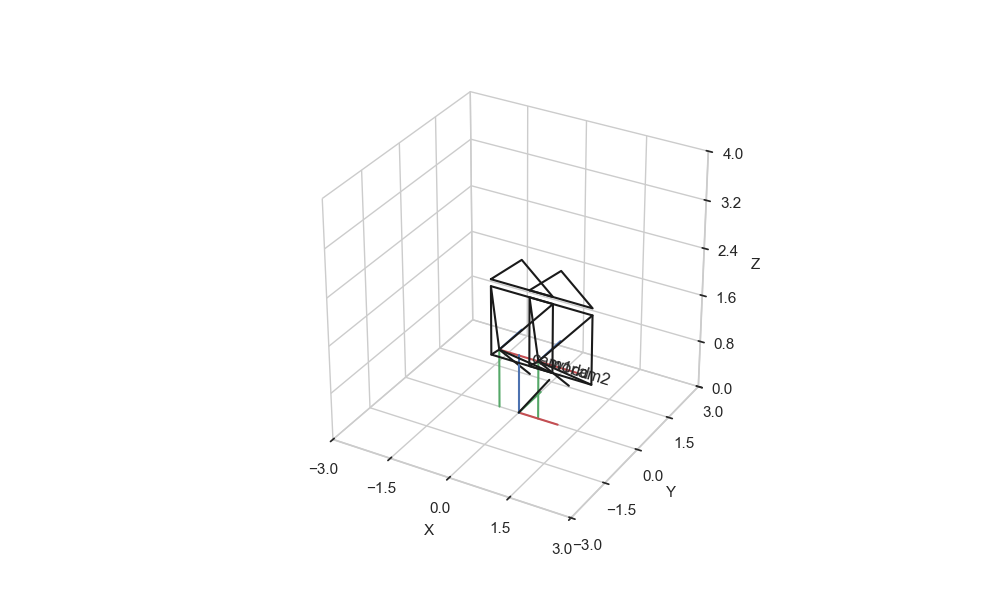

In [71]:
def make_stereo_setup() -> plt.Axes:
    plt.figure()
    ax = ppu.make_3d_axis(ax_s=3)
    ax.set_zbound(0, 4)
    ax.set_box_aspect((1, 1, 1))
    tm.plot_frames_in("world", ax=ax, ax_s=1)

    for cam in ["cam1", "cam2"]:
        pc.plot_camera(
            ax=ax,
            M=K,
            cam2world=tm.get_transform(from_frame=cam, to_frame="world"),
            sensor_size=(w_px, h_px),
            ax_s=1,
            virtual_image_distance=1,
        )

    return ax


make_stereo_setup()
plt.show()


## 7.1.4.4 Simulate 3D Points and Project onto Image Planes

Goal: simulate 80 3D points along a line and project them onto both camera planes. Use a parametric line with direction vector $\mathbf{d} = [1, 1, 0]^\top$ starting at $\mathbf{p}_0 = [-4, -4, 3]^\top$ and ending around $\mathbf{p}_1 = [4, 4, 3]^\top$. Sample evenly spaced values. Visualize the point cloud in 3D using `matplotlib`'s `Axes3D.scatter` or `pytransform3d`.

Then, perform these steps for each camera:
1. Transform the world points into the camera frame using the extrinsics from Section 7.1.4.2 (`pytransform3d.transform_manager` can apply transforms).
2. Project the camera-frame points to pixel coordinates with the pinhole model. You may implement the normalized projection manually or call `cv2.projectPoints` with `distCoeffs=None`.
3. Store the left-camera pixels in `pl` and the right-camera pixels in `pr` as $N\times2$ arrays.
4. Plot the projected points over blank image planes or use `seaborn.scatterplot` to inspect their distribution.

Reference: [Hartley & Zisserman, *Multiple View Geometry*, Chapter 6] and the [OpenCV projection tutorial](https://docs.opencv.org/4.x/d7/dff/tutorial_camera_calibration_basics.html).

> **Task**: implement the full simulation-to-projection pipeline, verify that both cameras receive consistent image coordinates, and save intermediate arrays for reuse in the next section.


### Pinhole Camera Projection Model

The pinhole camera model relates 3D points in camera coordinates to 2D image coordinates:

$$
s \begin{bmatrix} u \\ v \\ 1 \end{bmatrix} = \mathbf{K} \begin{bmatrix} X_c \\ Y_c \\ Z_c \end{bmatrix}
$$

where:
- $(X_c, Y_c, Z_c)$ are camera-frame coordinates
- $(u, v)$ are pixel coordinates
- $s = Z_c$ is the depth (scale factor)
- $\mathbf{K}$ is the 3×3 intrinsic matrix

**Two-Step Process:**
1. **Transform world → camera**: Apply extrinsics $(R, t)$: $\mathbf{x}_c = R\mathbf{x}_w + t$
2. **Project camera → image**: Apply intrinsics $\mathbf{K}$: $\mathbf{p}_{img} = \mathbf{K} \mathbf{x}_c / Z_c$

**Using OpenCV's projectPoints:**
- `cv2.projectPoints(points_3d, rvec, tvec, K, dist)` performs the full projection
- When points are already in camera coordinates, use `rvec=tvec=0` (identity pose)
- `dist=None` means no lens distortion correction

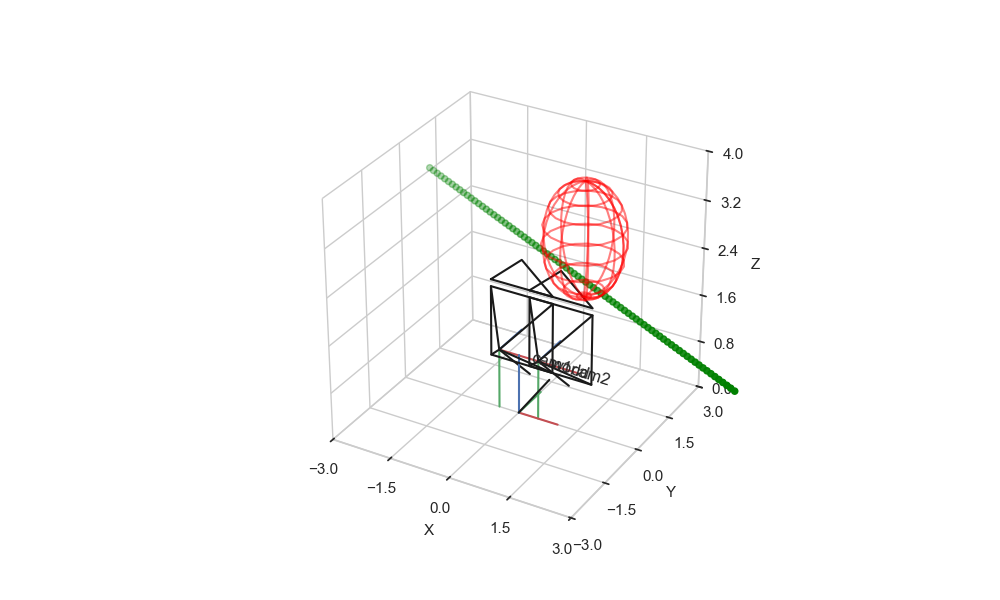

In [174]:
NUM_POINTS = 80
LINE_START = np.array([-4.0, 2.8, 2.6])  # Shift Y to positive in camera view
LINE_END = np.array([4.0, 2.8, 0.2])
DIRECTION = LINE_END - LINE_START


def sample_line(start: np.ndarray, direction: np.ndarray, n: int) -> np.ndarray:
    """Return N samples along a 3D line segment.

    The line is parameterized as: p(t) = start + t * direction, where t ∈ [0, 1]
    """
    ts = np.linspace(0.0, 1.0, n)[:, None]
    return start + ts * direction


pw = sample_line(LINE_START, DIRECTION, NUM_POINTS)


ax = make_stereo_setup()
ax.scatter(
    pw[:, 0],
    pw[:, 1],
    pw[:, 2],
    c="green",
    label="Simulated 3D points",
)
ppu.plot_sphere(ax, radius=1.0, p=[0, 3, 2], color="red", alpha=0.5)

plt.show()


## 7.1.4.5 Reconstruct 3D Points

Triangulate the 3D positions from the pixel correspondences $(pl_i, pr_i)$. Use the stereo geometry derived in lecture (intersection of rays) or leverage `cv2.triangulatePoints`. Ensure that you convert the homogeneous output back to Euclidean coordinates and express the result in the world frame.

Validation steps:
- Compare reconstructed points with the simulated ground truth using Euclidean error metrics (e.g., RMS error via `numpy.linalg.norm`).
- Add Gaussian pixel noise (e.g., `np.random.normal`) to `pl` and `pr`, rerun triangulation, and analyze the degradation.
- Visualize clean vs. noisy reconstructions in 3D. Use different colors (green for ground truth, blue for noisy, red for reconstructed) similar to the original MATLAB figure. `seaborn` can help with histograms of errors.

Reference: [Wikipedia: Triangulation (computer vision)](https://en.wikipedia.org/wiki/Triangulation_(computer_vision)) and the [OpenCV stereo triangulation guide](https://docs.opencv.org/4.x/d9/d0c/group__calib3d.html).

> **Task**: implement robust triangulation, metric evaluation, and noise analysis, documenting the numerical findings.


### Stereo Triangulation Theory

**The Problem:**
Given two cameras with known poses and intrinsics, and a pair of corresponding image points $(u_L, v_L)$ and $(u_R, v_R)$, reconstruct the 3D point.

**Mathematical Formulation:**
Each image point defines a ray in 3D space. For perfect data, these rays intersect at the 3D point. With noise, they may not intersect exactly, so we solve a least-squares problem.

For each camera $i$, we have:
$$
\lambda_i \begin{bmatrix} u_i \\ v_i \\ 1 \end{bmatrix} = \mathbf{P}_i \begin{bmatrix} X \\ Y \\ Z \\ 1 \end{bmatrix}
$$

where $\mathbf{P}_i = \mathbf{K}_i [\mathbf{R}_i | \mathbf{t}_i]$ is the $3 \times 4$ projection matrix.

**Direct Linear Transform (DLT):**
`cv2.triangulatePoints` uses DLT to solve the linear system formed by both cameras:
$$
\mathbf{A} \mathbf{X} = \mathbf{0}
$$
where $\mathbf{X}$ is the homogeneous 3D point and $\mathbf{A}$ stacks equations from both views. The solution minimizes algebraic error via SVD.

**Error Metrics:**
- **Reprojection error**: project reconstructed 3D points back to image and measure pixel distance
- **Euclidean error**: if ground truth is known, compute 3D distance
- **Sensitivity to noise**: pixel noise propagates to 3D; wider baseline reduces sensitivity

In [175]:
pw_h = np.hstack([pw, np.ones((pw.shape[0], 1))])
pw_h.shape


(80, 4)

In [176]:
def projection_matrix_from_transform(
    K: np.ndarray, T_world_cam: np.ndarray
) -> np.ndarray:
    """Compose a 3x4 projection matrix from intrinsics and extrinsics.

    Args
    ----
    intrinsics : np.ndarray
        3x3 intrinsic matrix K
    T_world_cam : np.ndarray
        4x4 homogeneous transform from world to camera

    Returns
    -------
    P : np.ndarray
        3x4 projection matrix: P = K @ [R | t]

    Notes
    -----
    The projection matrix P maps homogeneous world coordinates directly to homogeneous image coordinates:
        s * [u, v, 1]^T = P @ [X_w, Y_w, Z_w, 1]^T
    """
    return K @ T_world_cam[:3, :]


Pc1 = projection_matrix_from_transform(K, tm.get_transform("world", "cam1"))
Pc2 = projection_matrix_from_transform(K, tm.get_transform("world", "cam2"))
p_c1 = (Pc1 @ pw_h.T).T
p_c2 = (Pc2 @ pw_h.T).T

# Divide by depth to get [u, v]
pl = p_c1[:, :2] / p_c1[:, 2:3]
pr = p_c2[:, :2] / p_c2[:, 2:3]
print(f"pl.shape: {pl.shape}")


pl.shape: (80, 2)


In [177]:
print(f"  u: [{pl[:, 0].min():.2f}, {pl[:, 0].max():.2f}]")
print(f"  v: [{pl[:, 1].min():.2f}, {pl[:, 1].max():.2f}]")


  u: [-180.00, 962.86]
  v: [11.43, 354.29]


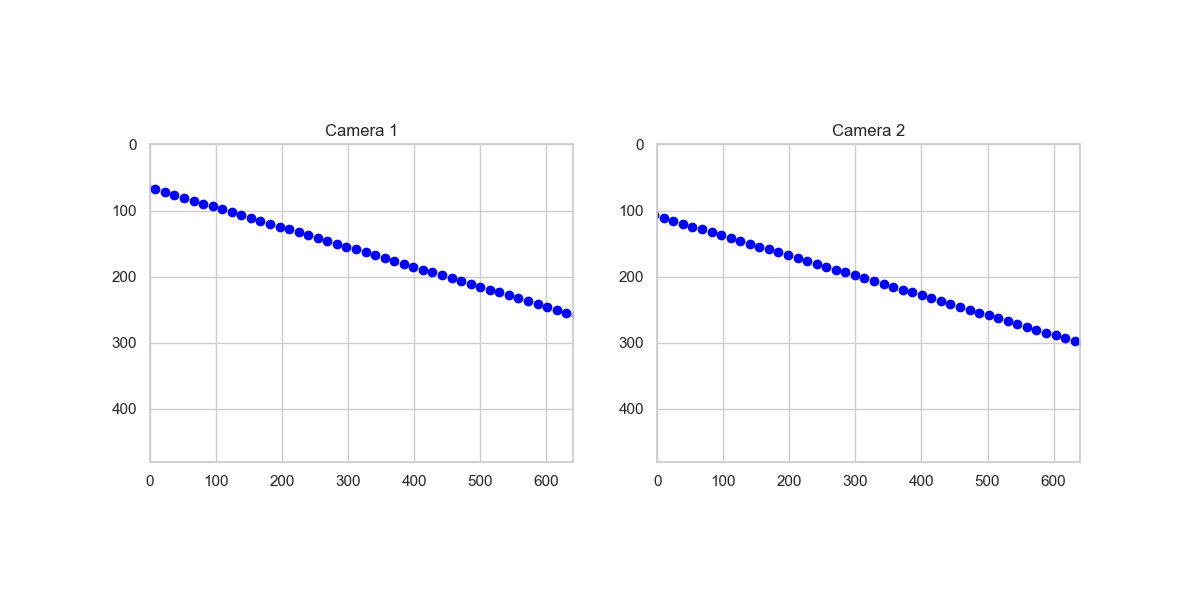

In [178]:
_, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.set_title("Camera 1")
ax1.scatter(
    pl[:, 0],
    pl[:, 1],
    c="blue",
    label="Projected points",
)

ax2.set_title("Camera 2")
ax2.scatter(
    pr[:, 0],
    pr[:, 1],
    c="blue",
    label="Projected points",
)

for ax in (ax1, ax2):
    ax.set_xlim(0, w_px)
    ax.set_ylim(h_px, 0)
    # set correct aspect ratio
    ax.set_aspect("equal", adjustable="box")

plt.show()


In [ ]:
def triangulate(
    pl: np.ndarray, pr: np.ndarray, P_left: np.ndarray, P_right: np.ndarray
) -> np.ndarray:
    """Triangulate homogeneous points and return in Euclidean coordinates.

    Args
    ----
    pl : np.ndarray
        Nx2 array of left camera pixel coordinates
    pr : np.ndarray
        Nx2 array of right camera pixel coordinates
    P_left : np.ndarray
        3x4 projection matrix for left camera
    P_right : np.ndarray
        3x4 projection matrix for right camera

    Returns
    -------
    points_3d : np.ndarray
        Nx3 array of triangulated 3D points in world coordinates

    Notes
    -----
    cv2.triangulatePoints solves the linear system:
        pl ~ P_left @ X
        pr ~ P_right @ X
    where X is the homogeneous 3D point [X, Y, Z, W]^T.

    The output is in homogeneous form, so we divide by W to get Euclidean coords.
    """
    homogeneous = cv2.triangulatePoints(P_left, P_right, pl.T, pr.T)
    points = (homogeneous[:3, :] / homogeneous[3, :]).T
    return points


pw_est = triangulate(
    pl=pl,
    pr=pr,
    P_left=Pc1,
    P_right=Pc2,
)
print(f"pw_est.shape: {pw_est.shape}")
print(f"MSE projection-error per axis: {np.mean((pw_est - pw) ** 2, axis=0)}")


pw_est.shape: (80, 3)
MSE projection-error per axis: [1.15141240e-30 1.68865538e-30 2.33779006e-31]


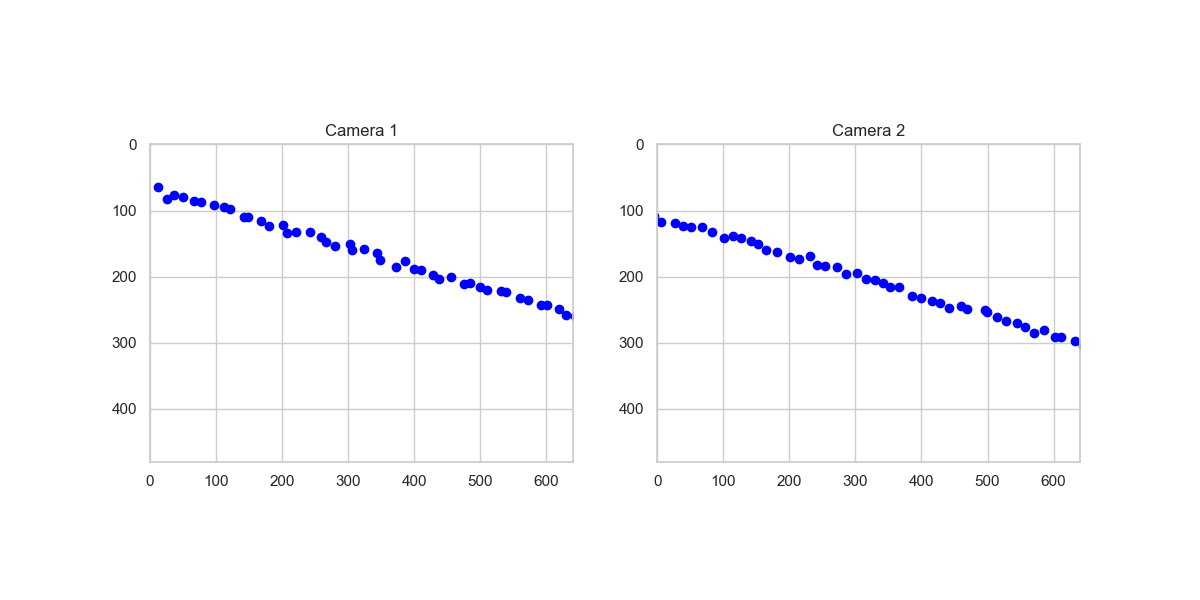

In [ ]:
pl_noisy = pl + np.random.normal(scale=3.0, size=pl.shape)
pr_noisy = pr + np.random.normal(scale=3.0, size=pr.shape)


_, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.set_title("Camera 1")
ax1.scatter(
    pl_noisy[:, 0],
    pl_noisy[:, 1],
    c="blue",
    label="Projected points",
)

ax2.set_title("Camera 2")
ax2.scatter(
    pr_noisy[:, 0],
    pr_noisy[:, 1],
    c="blue",
    label="Projected points",
)

for ax in (ax1, ax2):
    ax.set_xlim(0, w_px)
    ax.set_ylim(h_px, 0)
    # set correct aspect ratio
    ax.set_aspect("equal", adjustable="box")

plt.show()


pw_est.shape: (80, 3)
MSE projection-error per axis: [0.00359197 0.00560929 0.00053901]


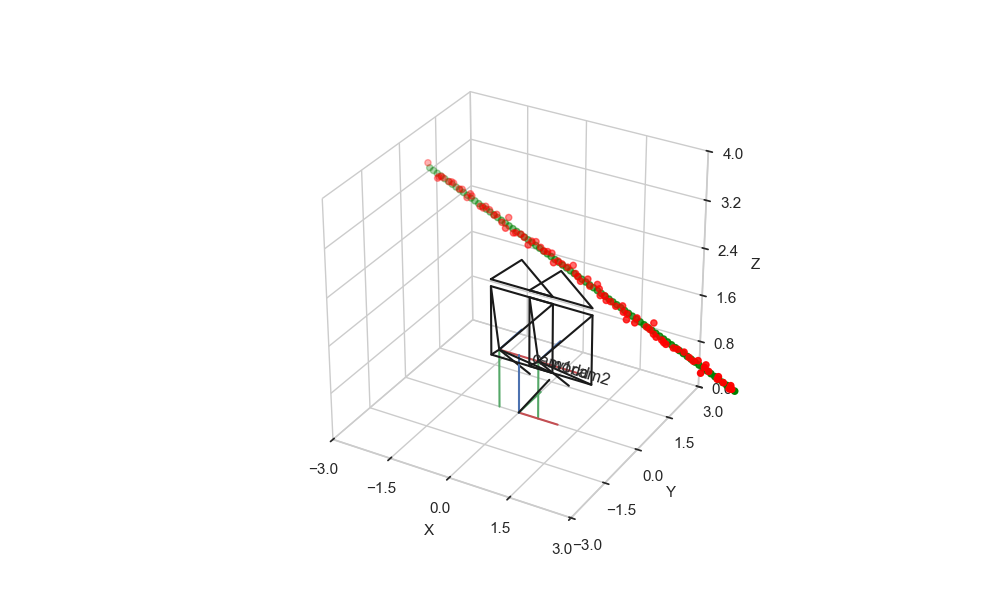

In [ ]:
pw_est = triangulate(
    pl=pl_noisy,
    pr=pr_noisy,
    P_left=Pc1,
    P_right=Pc2,
)
print(f"pw_est.shape: {pw_est.shape}")
print(f"MSE projection-error per axis: {np.mean((pw_est - pw) ** 2, axis=0)}")

ax = make_stereo_setup()
ax.scatter(
    pw[:, 0],
    pw[:, 1],
    pw[:, 2],
    c="green",
    label="Simulated 3D points",
)
ax.scatter(
    pw_est[:, 0],
    pw_est[:, 1],
    pw_est[:, 2],
    c="red",
    label="Reconstructed 3D points",
)

plt.show()
